In [1]:
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
# Carga documento

df_hr_limpio = pd.read_csv('../df_hr_limpio.csv')

1. **Cuanta gente se ha ido de la empresa. Cálculo en numero y en %** 

In [ ]:
# Conteo general y %
print(df_hr_limpio['attrition'].value_counts())
print("---" * 100)
print(df_hr_limpio['attrition'].value_counts(normalize=True) * 100)

attrition
No     1233
Yes     237
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


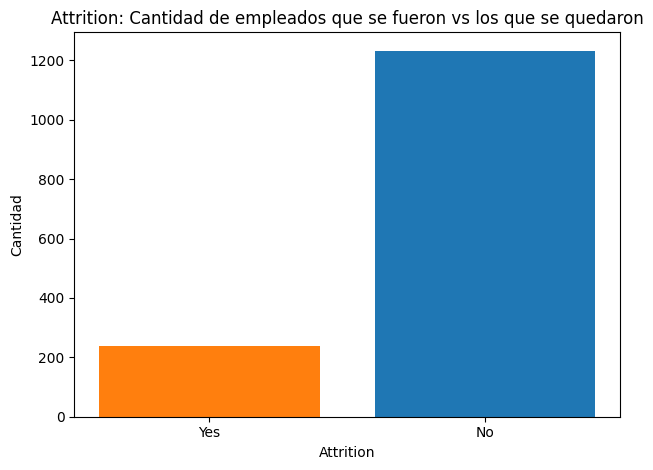

In [12]:
import matplotlib.pyplot as plt

plt.figure()

# Obtener datos
counts = df_hr_limpio['attrition'].value_counts()

# Ordenar y controlar colores
x = ['Yes', 'No']
y = [counts['Yes'], counts['No']]

# Asignar colores según tu solicitud
plt.bar(x, y, color=['tab:orange', 'tab:blue'])

plt.title('Attrition: Cantidad de empleados que se fueron vs los que se quedaron')
plt.xlabel('Attrition')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

Segun la IA, en análisis profesional se manejan estos rangos:


- Bajo	0–10%:
Plantilla estable, buen clima, buena retención

- Moderado	10–15%:
Normal en muchos sectores. Vigilancia ligera

- Alto	15–20%:
Ya indica posibles problemas internos

- Crítico	>20%: 	
Rotación peligrosa, impacto fuerte en costes y productividad

** nuestro resultado está dentro del rango moderado, pero no llega a sr crítico. Merece analizarse y detectar causas para prevención.

-------------------------------------------------------------------------------------------------

2. **Que edad tiene la gente que se ha ido de la empresa**

In [ ]:
edad_attrition = df_hr_limpio.groupby('attrition')['age'].describe()
edad_attrition

,count,mean,std,min,25%,50%,75%,max
attrition,,,,,,,,
No,1233.0,37.482563,8.650214,18.0,31.0,36.0,43.0,60.0
Yes,237.0,33.843882,9.373426,18.0,28.0,32.0,39.0,58.0


La media de edad de los trabajadores que se ha ido de la empresa (33) es más baja que la media de edad de los trabajadores de la empresa en general (37)

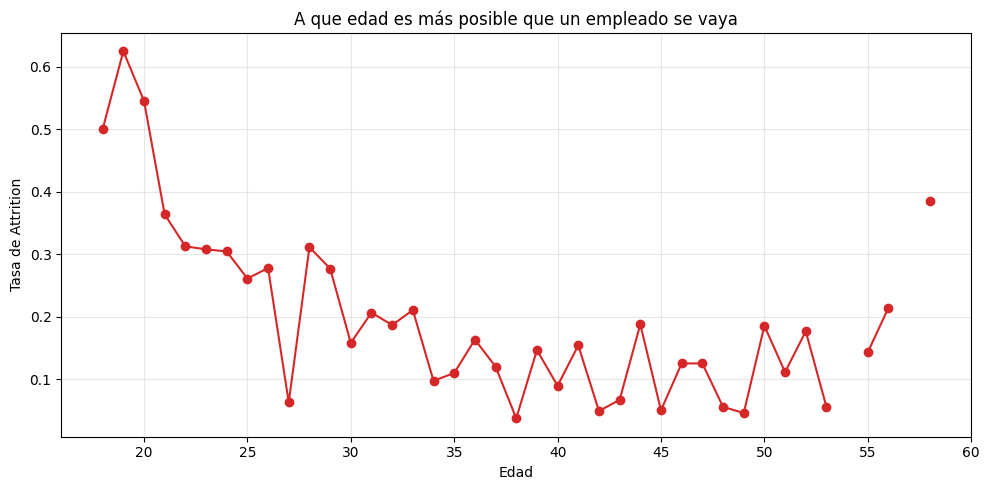

In [7]:
# Calcular tasa de attrition por edad
tabla = df_hr_limpio.groupby('age')['attrition'].value_counts(normalize=True).unstack()

# Nos quedamos con la columna "Yes" (tasa de abandono)
tasa = tabla['Yes']

plt.figure(figsize=(10,5))
plt.plot(tasa.index, tasa.values, marker='o', color='tab:red')
plt.title('A que edad es más posible que un empleado se vaya')
plt.xlabel('Edad')
plt.ylabel('Tasa de Attrition')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Hay dos grupos de riesgo: jóvenes y mayores.

- 20–25 → tasa alta
- 30–45 → tasa baja
- 55–60 → tasa alta

La probabilidad de irse no es lineal.
No depende de la media.
Depende de la edad concreta.

**los de 20 se van prácticamente todos y los de 60 también**

C:\Users\sanch\AppData\Local\Temp\ipykernel_19640\4130332083.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hr_limpio, x='attrition', y='age', palette=['tab:orange','tab:blue'])


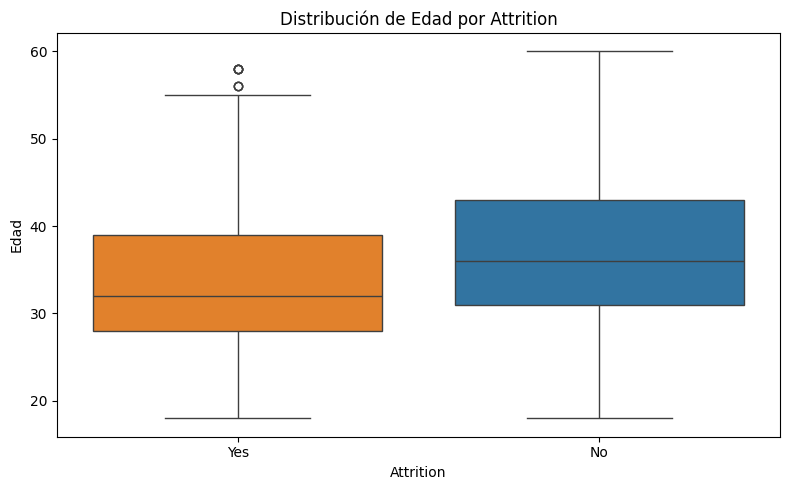

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_hr_limpio, x='attrition', y='age', palette=['tab:orange','tab:blue'])
plt.title('Distribución de Edad por Attrition')
plt.xlabel('Attrition')
plt.ylabel('Edad')
plt.tight_layout()
plt.show()


Los que se van tienden a ser más jóvenes, pero también hay un grupo de mayores que se van.


-------------------------------------------------------------------------------------------------

3. **comprobar si las personas que se han ido de la empresa han tenido aumentos de sueldo**

In [ ]:
# Aumentos de sueldo por attrition
aumentos = df_hr_limpio.groupby('attrition')['percent_salary_hike'].describe()
aumentos

,count,mean,std,min,25%,50%,75%,max
attrition,,,,,,,,
No,1233.0,15.231144,3.639511,11.0,12.0,14.0,18.0,25.0
Yes,237.0,15.097046,3.770294,11.0,12.0,14.0,17.0,25.0


El aumento de sueldo no parece influir en el hecho de que la gente se vaya.

C:\Users\sanch\AppData\Local\Temp\ipykernel_19640\1325116284.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


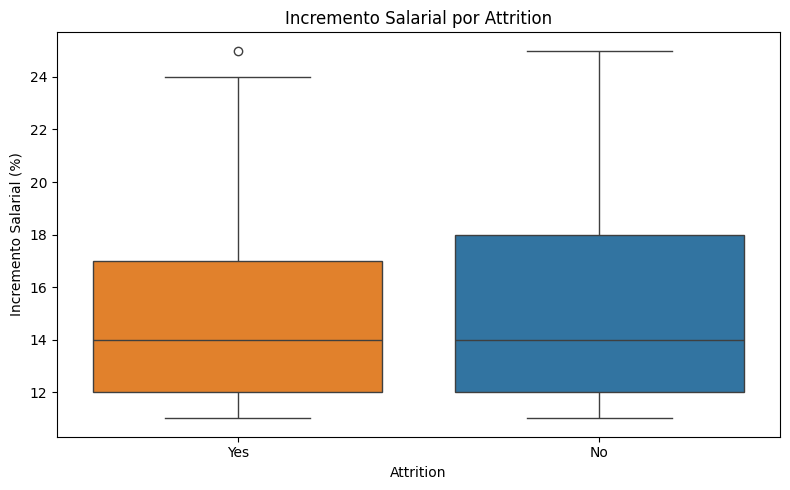

In [10]:
# Boxplot de incremento salarial por attrition

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_hr_limpio,
    x='attrition',
    y='percent_salary_hike',
    palette={'Yes': 'tab:orange', 'No': 'tab:blue'}
)
plt.title('Incremento Salarial por Attrition')
plt.xlabel('Attrition')
plt.ylabel('Incremento Salarial (%)')
plt.tight_layout()
plt.show()


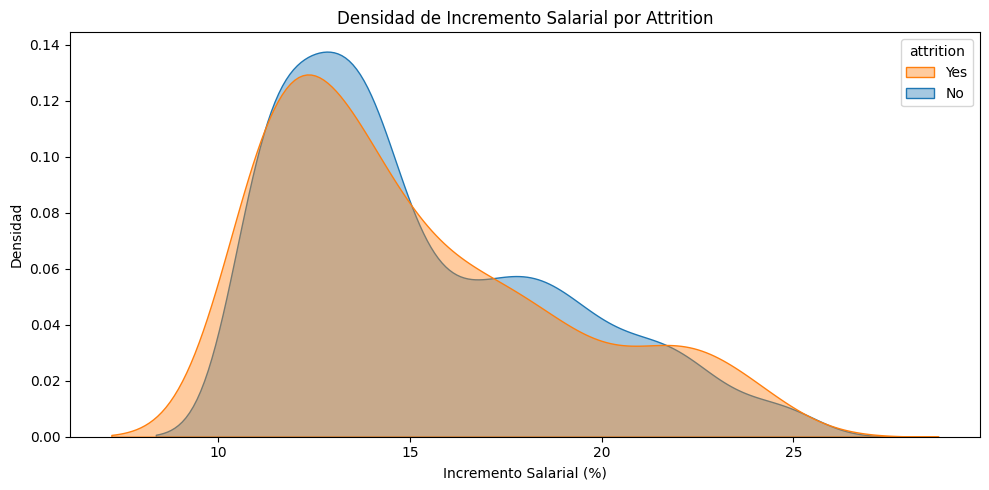

In [11]:
# ¿La distribución de incrementos es distinta entre los que se van y los que se quedan?

plt.figure(figsize=(10,5))
sns.kdeplot(
    data=df_hr_limpio,
    x='percent_salary_hike',
    hue='attrition',
    fill=True,
    common_norm=False,
    palette={'Yes': 'tab:orange', 'No': 'tab:blue'},
    alpha=0.4
)
plt.title('Densidad de Incremento Salarial por Attrition')
plt.xlabel('Incremento Salarial (%)')
plt.ylabel('Densidad')
plt.tight_layout()
plt.show()


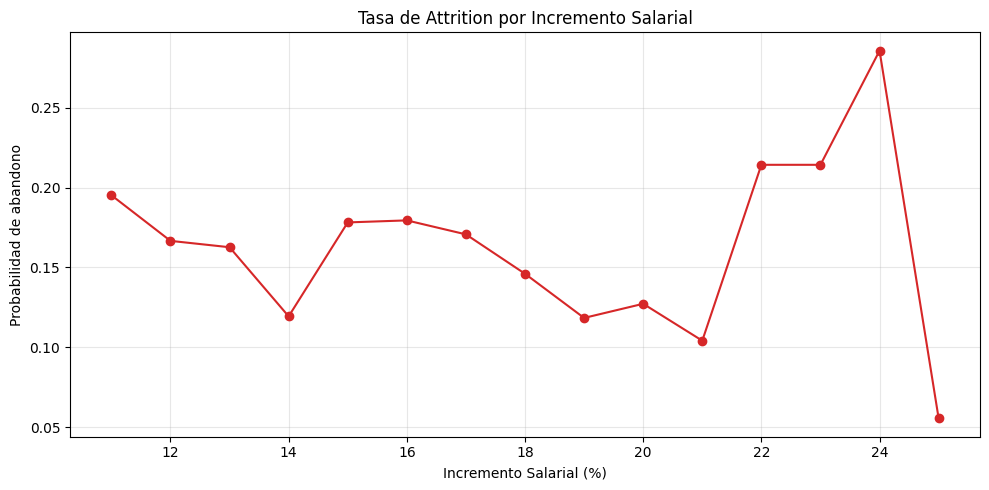

In [13]:
# ¿Cuál es la proporción de empleados que se van según el nivel de incremento salarial?


tabla = df_hr_limpio.groupby('percent_salary_hike')['attrition'].value_counts(normalize=True).unstack()

tasa = tabla['Yes']

plt.figure(figsize=(10,5))
plt.plot(tasa.index, tasa.values, marker='o', color='tab:red')
plt.title('Tasa de Attrition por Incremento Salarial')
plt.xlabel('Incremento Salarial (%)')
plt.ylabel('Probabilidad de abandono')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**No hay relación clara entre el incremento salarial y la probabilidad de que un empleado se vaya.**

-------------------------------------------------------------------------------------------------

4. **comprobar si hay relacion entre los trabajadores que se fueron y las horas extra**

In [17]:
# si hacen horas extra

# Horas extra por attrition
horas_extra = df_hr_limpio.groupby(['attrition', 'over_time']).size().unstack().fillna(0).reset_index()
horas_extra


over_time,attrition,No,Yes
0,No,953,280
1,Yes,112,125


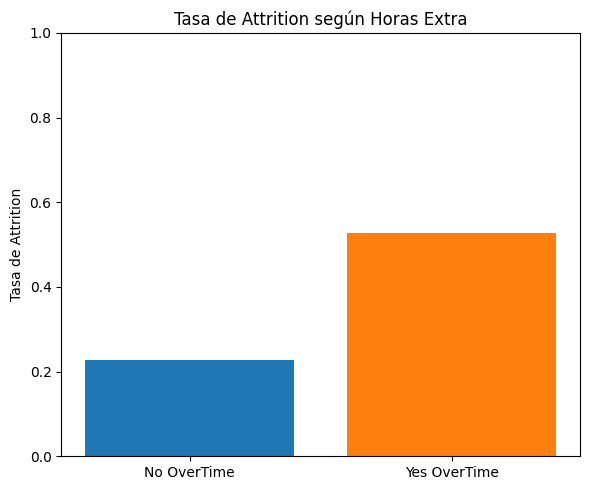

In [14]:
tasa_no = 280 / (953 + 280)
tasa_yes = 125 / (112 + 125)

plt.figure(figsize=(6,5))
plt.bar(['No OverTime', 'Yes OverTime'], [tasa_no, tasa_yes],
        color=['tab:blue', 'tab:orange'])

plt.title('Tasa de Attrition según Horas Extra')
plt.ylabel('Tasa de Attrition')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


Los empleados que hacen horas extra tienen más del doble de probabilidad de irse que los que no hacen horas extra.

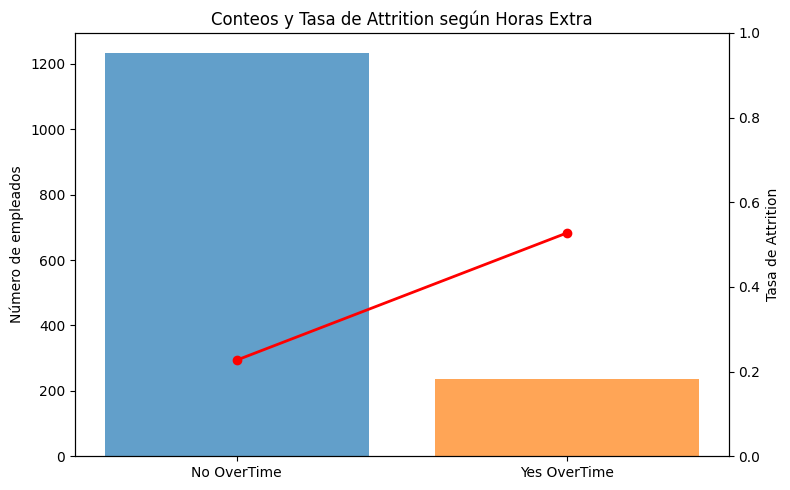

In [15]:

# Datos
no_ot_stay = 953
no_ot_leave = 280
yes_ot_stay = 112
yes_ot_leave = 125

# Conteos totales
tot_no = no_ot_stay + no_ot_leave
tot_yes = yes_ot_stay + yes_ot_leave

# Tasas
tasa_no = no_ot_leave / tot_no
tasa_yes = yes_ot_leave / tot_yes

# Preparar datos
labels = ['No OverTime', 'Yes OverTime']
conteos = [tot_no, tot_yes]
tasas = [tasa_no, tasa_yes]

fig, ax1 = plt.subplots(figsize=(8,5))

# Barras de conteo
ax1.bar(labels, conteos, color=['tab:blue','tab:orange'], alpha=0.7)
ax1.set_ylabel('Número de empleados')
ax1.set_title('Conteos y Tasa de Attrition según Horas Extra')

# Eje secundario para la tasa
ax2 = ax1.twinx()
ax2.plot(labels, tasas, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Tasa de Attrition')
ax2.set_ylim(0,1)

plt.tight_layout()
plt.show()

In [16]:
data = {
    'OverTime': ['No', 'Yes'],
    'Se_quedan': [953, 112],
    'Se_van': [280, 125]
}

df_ot = pd.DataFrame(data)
df_ot['Total'] = df_ot['Se_quedan'] + df_ot['Se_van']
df_ot['Tasa_attrition'] = df_ot['Se_van'] / df_ot['Total']

df_ot


,OverTime,Se_quedan,Se_van,Total,Tasa_attrition
0,No,953,280,1233,0.227088
1,Yes,112,125,237,0.527426


- 22.7% de los empleados que NO hacen horas extra se van.
- 52.7% de los empleados que SÍ hacen horas extra se van.
La probabilidad de irse es más del doble entre quienes hacen horas extra


-----------------------------------------------------------------------------------------------------------------------------------

5. **Ver la antigüedad media de los trabajadores que se van de la empresa, ya que joven no tiene por que significar que lleva poco tiempo.**

In [18]:
df_hr_limpio.groupby('attrition')['years_at_company'].mean()

attrition
No     7.369019
Yes    5.130802
Name: years_at_company, dtype: float64

In [19]:
df_hr_limpio.groupby('attrition')['years_at_company'].agg(['count','mean','std','min','median','max'])

,count,mean,std,min,median,max
attrition,,,,,,
No,1233,7.369019,6.096298,0,6.0,37
Yes,237,5.130802,5.949984,0,3.0,40


In [22]:
df_hr_limpio[df_hr_limpio['attrition'] == 'Yes']['years_at_company'].value_counts().sort_index()

years_at_company
0     16
1     59
2     27
3     20
4     19
5     21
6      9
7     11
8      9
9      8
10    18
11     2
13     2
14     2
15     1
16     1
17     1
18     1
19     1
20     1
21     1
22     1
23     1
24     1
31     1
32     1
33     1
40     1
Name: count, dtype: int64

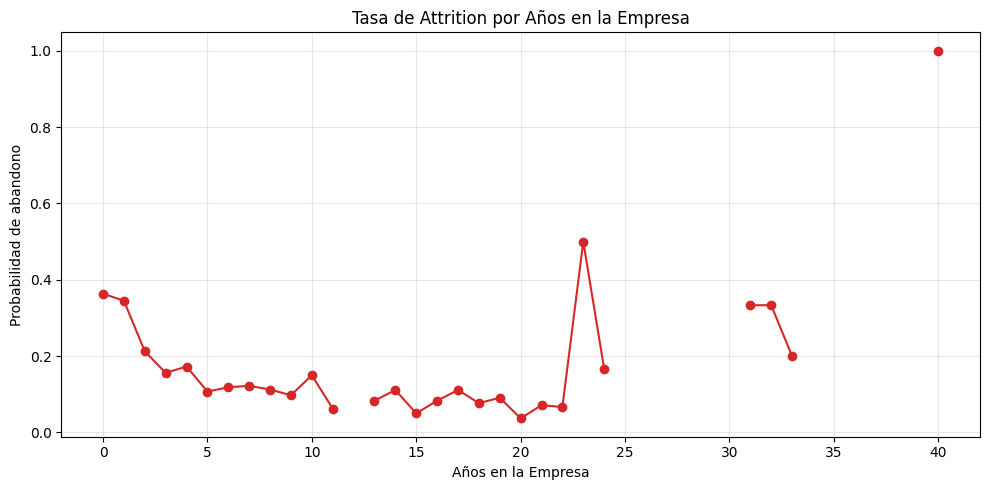

In [21]:

# Calcular la tasa de attrition por antigüedad
tabla = df_hr_limpio.groupby('years_at_company')['attrition'].value_counts(normalize=True).unstack()

tasa = tabla['Yes']   # Probabilidad de irse en cada año

plt.figure(figsize=(10,5))
plt.plot(tasa.index, tasa.values, marker='o', color='tab:red')
plt.title('Tasa de Attrition por Años en la Empresa')
plt.xlabel('Años en la Empresa')
plt.ylabel('Probabilidad de abandono')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El riesgo de abandono es mayor en los primeros años de antigüedad.
Después de cierto punto, la gente se estabiliza.
Vuelve a subir con bastantes años en la empresa, posiblemente por prejubilación/jubilacion


--------------------------------------------------------

**Conclusiones generales**

- El aumento de sueldo no explica por que la gente se va de la empresa. No es un factor relevante para el abandono.
- Las horas extra están fuertemente asociadas al abandono. Son un factor crítico. Los empleados que hacen horas extra tienen más del doble de probabilidad de irse que los que no las hacen.
- La antigüedad es un factor relevante: el abandono es más frecuente en los primeros años. La estructura de antigüedad de la plantilla influye en el patrón de abandono. --> periodo crítico para la retención.

